In [1]:
import os

In [2]:
%pwd

'c:\\Users\\hulkh\\Desktop\\Python\\supplier_clustering\\Supplier_clustering\\research'

In [3]:
os.chdir("../")

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv("artifacts/data_ingestion/purchase_orders.csv")
df.head()

,po_id,order_date,promised_delivery_date,actual_delivery_date,supplier_id,supplier_name,supplier_country,category,item,business_unit,unit_price,quantity,line_total,payment_terms,on_contract,quality_rejected
0,PO-2023-00441,2023-01-01,2023-01-09,2023-01-11,SUP-038,Bergmann MRO Services,Germany,MRO,Safety Gloves (per 100),Manufacturing,102.23,22,2249.06,Net 45,True,False
1,PO-2023-00598,2023-01-01,2023-01-27,2023-01-27,SUP-053,Sterling Shipping Lines,USA,Logistics,Ocean Container (40ft),Retail Operations,3271.58,2,6543.16,Net 30,True,False
2,PO-2023-00300,2023-01-01,2023-01-09,2023-01-09,SUP-022,Redwood Components,USA,Electronics,Power Supply Unit 450W,Retail Operations,60.25,179,10784.75,Net 15,True,False
3,PO-2023-00169,2023-01-01,2023-01-09,2023-01-09,SUP-016,Great Wall Containers,China,Packaging,Wooden Pallets,Manufacturing,15.62,247,3858.14,Net 15,True,False
4,PO-2023-00280,2023-01-01,2023-02-02,2023-02-02,SUP-036,Golden Dragon Components,China,Electronics,Connector Kit CK-8,Corporate,4.30,927,3986.10,Net 45,True,False


In [7]:
df.sample(10)

,po_id,order_date,promised_delivery_date,actual_delivery_date,supplier_id,supplier_name,supplier_country,category,item,business_unit,unit_price,quantity,line_total,payment_terms,on_contract,quality_rejected
7536,PO-2023-07633,2023-08-03,2023-08-31,2023-08-31,SUP-016,Great Wall Containers,China,Packaging,Printed Labels (per 1000),Corporate,41.57,77,3200.89,Net 45,True,False
18013,PO-2024-18087,2024-05-01,2024-05-28,2024-05-28,SUP-003,Jade Harbor Alloys,China,Raw Materials,Polypropylene Resin (per ton),Corporate,1426.94,27,38527.38,Net 60,True,True
4076,PO-2023-03741,2023-04-25,2023-05-02,2023-05-02,SUP-038,Bergmann MRO Services,Germany,MRO,Safety Gloves (per 100),Manufacturing,117.43,20,2348.60,Net 45,True,False
42907,PO-2026-43328,2026-03-06,2026-03-14,2026-03-14,SUP-049,Han River Freight,South Korea,Logistics,FTL Freight (per load),Field Services,1936.23,3,5808.69,Net 30,False,False
4577,PO-2023-04955,2023-05-09,2023-05-28,2023-05-28,SUP-061,Shenzhou IT Solutions,China,IT Services,Cybersecurity Audit,Field Services,9324.37,1,9324.37,Net 30,False,False
9589,PO-2023-09529,2023-09-30,2023-10-17,2023-10-17,SUP-095,Busan Machinery,South Korea,Machinery,Precision Jig Set,Retail Operations,2440.96,2,4881.92,Net 30,True,False
12581,PO-2023-13590,2023-12-05,2023-12-24,2023-12-24,SUP-082,Himalaya Chemicals,India,Chemicals,Industrial Solvent (drum),Retail Operations,371.48,7,2600.36,Net 45,True,True
45008,PO-2026-45761,2026-05-03,2026-05-27,2026-05-27,SUP-072,Krakow Office Products,Poland,Office Supplies,Stationery Kit,Manufacturing,19.72,59,1163.48,Net 15,True,True
25125,PO-2024-25429,2024-11-16,2024-12-09,2024-12-13,SUP-072,Krakow Office Products,Poland,Office Supplies,Copy Paper (per case),Field Services,33.38,41,1368.58,Net 30,True,False
13669,PO-2023-13746,2023-12-29,2024-01-28,2024-01-28,SUP-100,Cascade Advisory,USA,Professional Services,Training Programme,Corporate,4275.37,2,8550.74,Net 45,True,False


In [8]:
df.isnull().sum()

po_id                     0
order_date                0
promised_delivery_date    0
actual_delivery_date      0
supplier_id               0
supplier_name             0
supplier_country          0
category                  0
item                      0
business_unit             0
unit_price                0
quantity                  0
line_total                0
payment_terms             0
on_contract               0
quality_rejected          0
dtype: int64

In [9]:
df['po_id'].nunique()

47128

In [10]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

po_id: 47128 unique values
order_date: 1277 unique values
promised_delivery_date: 1304 unique values
actual_delivery_date: 1310 unique values
supplier_id: 106 unique values
supplier_name: 106 unique values
supplier_country: 10 unique values
category: 10 unique values
item: 50 unique values
business_unit: 5 unique values
unit_price: 36299 unique values
quantity: 2587 unique values
line_total: 45719 unique values
payment_terms: 4 unique values
on_contract: 2 unique values
quality_rejected: 2 unique values


In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['unit_price', 'quantity', 'line_total']

In [12]:
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()

    if negative_count > 0:
        print(f"{col} has {negative_count} negative values")
    else:
        print(f"{col} has no negative values")

unit_price has no negative values
quantity has no negative values
line_total has no negative values


In [13]:
df.columns

Index(['po_id', 'order_date', 'promised_delivery_date', 'actual_delivery_date',
       'supplier_id', 'supplier_name', 'supplier_country', 'category', 'item',
       'business_unit', 'unit_price', 'quantity', 'line_total',
       'payment_terms', 'on_contract', 'quality_rejected'],
      dtype='object')

In [14]:
date_columns=['order_date','promised_delivery_date','actual_delivery_date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [15]:
df['order_date'].dtypes

dtype('<M8[ns]')

In [16]:
df['delivery_delay'] = (df['actual_delivery_date']-df['promised_delivery_date']).dt.days

In [17]:
df['delivery_delay']

0        2
1        0
2        0
3        0
4        0
        ..
47123    0
47124    0
47125    0
47126    0
47127    0
Name: delivery_delay, Length: 47128, dtype: int64

In [18]:
df['on_time'] = df['delivery_delay'].apply(lambda x: 1 if x<=0 else 0)

## Exploratory Data Analysis

In [19]:
df['supplier_id'].nunique()

106

In [20]:
df.columns

Index(['po_id', 'order_date', 'promised_delivery_date', 'actual_delivery_date',
       'supplier_id', 'supplier_name', 'supplier_country', 'category', 'item',
       'business_unit', 'unit_price', 'quantity', 'line_total',
       'payment_terms', 'on_contract', 'quality_rejected', 'delivery_delay',
       'on_time'],
      dtype='object')

In [21]:
supplier_orders = df.groupby('supplier_name')['po_id'].count().sort_values(ascending=False).reset_index().rename(columns={'po_id':'total_orders'})
supplier_orders

,supplier_name,total_orders
0,Great Wall Containers,5384
1,Taegu Alloys,4172
2,Krakow Office Products,2462
3,Shenzhou Transport,2212
4,Thames Industrial Supply,1848
...,...,...
101,Sterling Technologies,7
102,Frontier Packaging,6
103,Azteca Pack Solutions,5
104,Sterling Chem Industries,4


In [22]:
supplier_spend = df.groupby('supplier_name')['line_total'].sum().sort_values(ascending=False).reset_index().rename(columns={'line_total':'total_spend'})
supplier_spend


,supplier_name,total_spend
0,Taegu Alloys,83912380.83
1,Great Wall Containers,24672186.74
2,Summit Components,21206582.00
3,Cascade Semitech,16010733.91
4,Adler Metals,13568470.46
...,...,...
101,Mekong Supplies Co,24136.62
102,Bharat Specialty Chem,22486.71
103,Sterling Chem Industries,17486.20
104,Azteca Pack Solutions,16616.72


<Axes: >

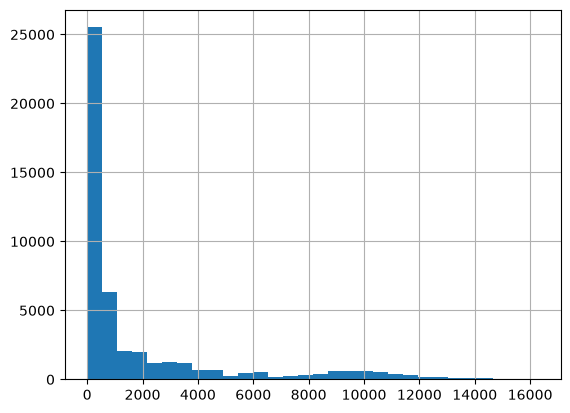

In [23]:
# plot for unit price distribution
df['unit_price'].hist(bins=30)

## Price Competitiveness

In [24]:
item_avg_price = df.groupby('item')['unit_price'].mean().reset_index().rename(columns={"unit_price": "item_avg_price"})
item_avg_price.head()

,item,item_avg_price
0,Adhesive Compound (drum),666.035724
1,Air Freight (per 100kg),655.106507
2,Aluminium Sheet (per ton),2650.276312
3,Audit & Compliance Review,10561.797724
4,Bubble Wrap Rolls,29.754224


In [25]:
df = df.merge(item_avg_price, on="item",how="left")

In [26]:
df['price_ratio']= df['unit_price']/df['item_avg_price']

In [27]:
df['price_ratio']

0        0.981662
1        0.946873
2        0.793142
3        0.942017
4        0.843380
           ...   
47123    1.037827
47124    1.102895
47125    1.150472
47126    1.243570
47127    1.212267
Name: price_ratio, Length: 47128, dtype: float64

0.85 → supplier is 15% cheaper than item average
1.00 → around average
1.20 → supplier is 20% more expensive

### Price competitiveness

In [28]:
# 1
price_competitiveness = df.groupby('supplier_id')['price_ratio'].mean()
price_competitiveness

supplier_id
SUP-001    0.972818
SUP-002    0.970539
SUP-003    1.090915
SUP-004    1.051534
SUP-005    1.099693
             ...   
SUP-102    0.908411
SUP-103    1.071268
SUP-104    1.056981
SUP-105    1.079207
SUP-106    1.015862
Name: price_ratio, Length: 106, dtype: float64

### Cost Variabiility

To know if prices are stable

In [29]:
df["item_supplier_price_cv"] = (
    df.groupby(["supplier_id", "item"])["unit_price"]
      .transform(lambda x: x.std() / x.mean())
)

In [30]:
cost_variability = (
    df.groupby("supplier_id")["item_supplier_price_cv"]
      .mean()
)

In [31]:
cost_variability

supplier_id
SUP-001    0.090826
SUP-002    0.089811
SUP-003    0.088498
SUP-004    0.084760
SUP-005    0.082324
             ...   
SUP-102    0.060653
SUP-103    0.063343
SUP-104    0.054959
SUP-105    0.064942
SUP-106    0.053352
Name: item_supplier_price_cv, Length: 106, dtype: float64

SUP-001 has the highest cost variability, indicating that its prices are relatively more variable across the items/transactions it supplies compared with other suppliers. This may indicate less consistent pricing across its supplied items.

### Total spend

In [32]:
total_spend = (
    df.groupby("supplier_id")["line_total"]
      .sum()
)


### Quality Rejection Rate

In [33]:
quality_rejection_rate = (
    df.groupby("supplier_id")["quality_rejected"]
      .mean()
)

### On-Time Delivery Rate

In [34]:
on_time_delivery_rate = (
    df.groupby("supplier_id")["on_time"]
      .mean()
)

### Average Delivery Delay

In [35]:
average_delivery_delay = (
    df.groupby("supplier_id")["delivery_delay"]
      .mean()
)

### Order Frequency

In [36]:
order_frequency = (df.groupby("supplier_id")["po_id"].nunique())
order_frequency

supplier_id
SUP-001     107
SUP-002    4172
SUP-003     456
SUP-004      67
SUP-005     127
           ... 
SUP-102     710
SUP-103     156
SUP-104      21
SUP-105     708
SUP-106      58
Name: po_id, Length: 106, dtype: int64

### Average Late days

In [37]:
# Late days
# Average late days → When they are late, how severe is the delay?

df["late_days"] = df["delivery_delay"].clip(lower=0)
average_late_days = (
    df.groupby("supplier_id")["late_days"]
      .mean()
      .rename("average_late_days")
)

df = df.merge(
    average_late_days,
    on="supplier_id",
    how="left"
)

In [38]:
supplier_features = pd.DataFrame({
    "price_competitiveness": price_competitiveness,
    "cost_variability": cost_variability,
    "total_spend": total_spend,
    "order_frequency": order_frequency,
    "average_delivery_delay": average_delivery_delay,
    "quality_rejection_rate": quality_rejection_rate,
    "on_time_delivery_rate": on_time_delivery_rate,
    "average_late_days": average_late_days
})

In [39]:
supplier_features.head()

,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
supplier_id,,,,,,,,
SUP-001,0.972818,0.090826,2180952.04,107,0.121495,0.009346,0.934579,0.121495
SUP-002,0.970539,0.089811,83912380.83,4172,0.257910,0.014621,0.891419,0.257910
SUP-003,1.090915,0.088498,10388962.85,456,0.370614,0.017544,0.868421,0.370614
SUP-004,1.051534,0.084760,1426125.23,67,0.208955,0.000000,0.910448,0.208955
SUP-005,1.099693,0.082324,2972062.85,127,0.330709,0.007874,0.874016,0.330709


In [40]:
supplier_features.isnull().sum()

price_competitiveness     0
cost_variability          0
total_spend               0
order_frequency           0
average_delivery_delay    0
quality_rejection_rate    0
on_time_delivery_rate     0
average_late_days         0
dtype: int64

In [41]:
np.isinf(supplier_features).sum()

price_competitiveness     0
cost_variability          0
total_spend               0
order_frequency           0
average_delivery_delay    0
quality_rejection_rate    0
on_time_delivery_rate     0
average_late_days         0
dtype: int64

In [44]:
supplier_features.describe()

,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
count,106.000000,106.000000,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000
mean,0.993467,0.080349,3.879088e+06,444.603774,0.862463,0.017964,0.836586,0.862463
std,0.066226,0.036096,9.194998e+06,798.817873,2.406002,0.027652,0.203117,2.406002
min,0.860772,0.014846,1.638747e+04,3.000000,0.000000,0.000000,0.000000,0.000000
25%,0.942912,0.053354,1.387961e+05,37.250000,0.205151,0.000000,0.869916,0.205151
50%,1.002002,0.065603,8.974078e+05,127.500000,0.261013,0.011528,0.893593,0.261013
75%,1.044056,0.111058,4.492715e+06,539.750000,0.332677,0.019713,0.902629,0.332677
max,1.161405,0.185699,8.391238e+07,5384.000000,11.005181,0.160000,1.000000,11.005181


In [45]:
for col in supplier_features.columns:
    Q1 = supplier_features[col].quantile(0.25)
    Q3 = supplier_features[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = supplier_features[
        (supplier_features[col] < lower_bound) |
        (supplier_features[col] > upper_bound)
    ]

    print(f"Outliers in {col}:")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    print("-" * 50)

Outliers in price_competitiveness:
Q1: 0.9429115831612351
Q3: 1.044056051669349
IQR: 0.10114446850811376
Lower bound: 0.7911948803990645
Upper bound: 1.1957727544315195
Number of outliers: 0
--------------------------------------------------
Outliers in cost_variability:
Q1: 0.053354024897444195
Q3: 0.11105776940849231
IQR: 0.057703744511048115
Lower bound: -0.033201591869127973
Upper bound: 0.19761338617506446
Number of outliers: 0
--------------------------------------------------
Outliers in total_spend:
Q1: 138796.1325
Q3: 4492714.837499999
IQR: 4353918.704999999
Lower bound: -6392081.924999999
Upper bound: 11023592.895
Number of outliers: 11
--------------------------------------------------
Outliers in order_frequency:
Q1: 37.25
Q3: 539.75
IQR: 502.5
Lower bound: -716.5
Upper bound: 1293.5
Number of outliers: 10
--------------------------------------------------
Outliers in average_delivery_delay:
Q1: 0.20515142732937255
Q3: 0.3326771653543307
IQR: 0.12752573802495812
Lower bound

In [46]:
skewness = supplier_features.skew(numeric_only=True)
print(skewness)

price_competitiveness    -0.083209
cost_variability          0.707082
total_spend               6.635875
order_frequency           3.717419
average_delivery_delay    3.864803
quality_rejection_rate    3.011462
on_time_delivery_rate    -3.445044
average_late_days         3.864803
dtype: float64


In [42]:
corr = supplier_features.corr()
corr

,price_competitiveness,cost_variability,total_spend,order_frequency,average_delivery_delay,quality_rejection_rate,on_time_delivery_rate,average_late_days
price_competitiveness,1.000000,-0.042901,0.059236,0.055424,-0.065270,-0.005787,0.054397,-0.065270
cost_variability,-0.042901,1.000000,0.184900,0.032602,0.475892,0.507433,-0.464426,0.475892
total_spend,0.059236,0.184900,1.000000,0.728739,0.009069,0.051369,0.005467,0.009069
order_frequency,0.055424,0.032602,0.728739,1.000000,0.024518,0.078642,0.000081,0.024518
average_delivery_delay,-0.065270,0.475892,0.009069,0.024518,1.000000,0.874685,-0.973648,1.000000
quality_rejection_rate,-0.005787,0.507433,0.051369,0.078642,0.874685,1.000000,-0.834632,0.874685
on_time_delivery_rate,0.054397,-0.464426,0.005467,0.000081,-0.973648,-0.834632,1.000000,-0.973648
average_late_days,-0.065270,0.475892,0.009069,0.024518,1.000000,0.874685,-0.973648,1.000000


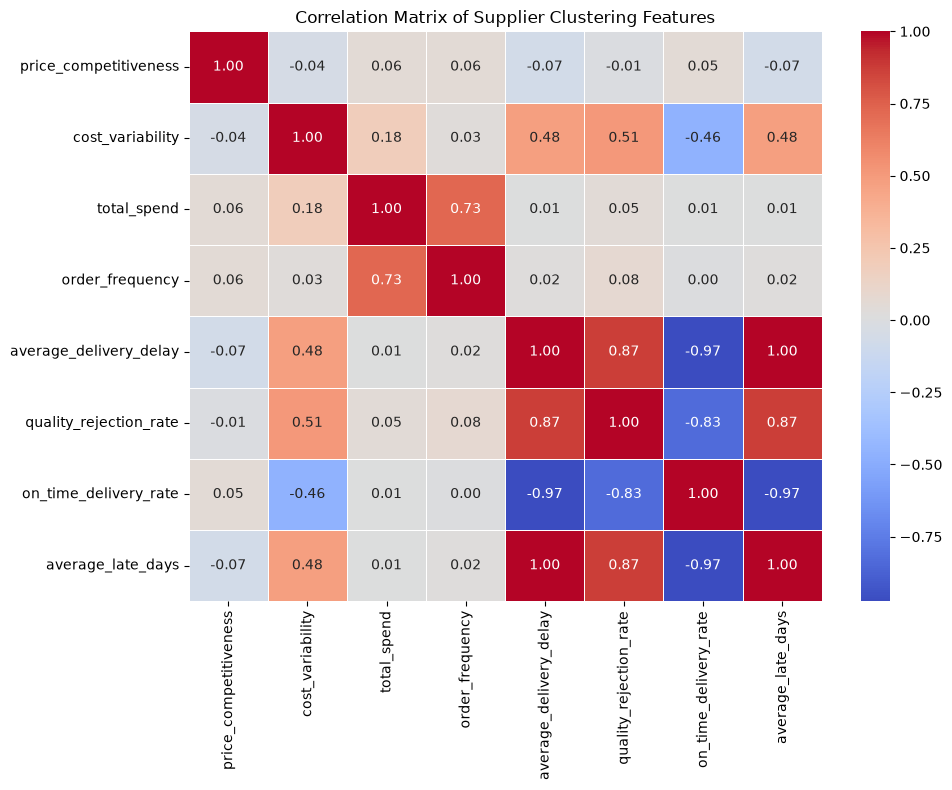

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Supplier Clustering Features")
plt.tight_layout()
plt.show()

| Feature                  | Outliers |   Skewness | What it tells us                             |
| ------------------------ | -------: | ---------: | -------------------------------------------- |
| `price_competitiveness`  |        0 |     -0.083 | Very well behaved                            |
| `cost_variability`       |        0 |      0.707 | Moderately right-skewed, but no IQR outliers |
| `total_spend`            |       11 |  **6.636** | Extremely right-skewed                       |
| `order_frequency`        |       10 |  **3.717** | Strongly right-skewed                        |
| `average_delivery_delay` |       16 |  **3.865** | Strongly right-skewed                        |
| `quality_rejection_rate` |        7 |  **3.011** | Strongly right-skewed                        |
| `on_time_delivery_rate`  |       20 | **-3.445** | Strongly left-skewed                         |
| `average_late_days`      |       16 |  **3.865** | Strongly right-skewed                        |


High -ve correlation between average_delivery_delay and on_time_delivery_rate. So dropping average_delivery_delay from the features because the other is more easier to understand

In [43]:
supplier_features.drop(columns=['average_delivery_delay'], inplace=True)

In [44]:
supplier_features

,price_competitiveness,cost_variability,total_spend,order_frequency,quality_rejection_rate,on_time_delivery_rate
supplier_id,,,,,,
SUP-001,0.972818,0.090826,2180952.04,107,0.009346,0.934579
SUP-002,0.970539,0.089811,83912380.83,4172,0.014621,0.891419
SUP-003,1.090915,0.088498,10388962.85,456,0.017544,0.868421
SUP-004,1.051534,0.084760,1426125.23,67,0.000000,0.910448
SUP-005,1.099693,0.082324,2972062.85,127,0.007874,0.874016
...,...,...,...,...,...,...
SUP-102,0.908411,0.060653,5689957.03,710,0.023944,0.911268
SUP-103,1.071268,0.063343,1482987.60,156,0.012821,0.858974
SUP-104,1.056981,0.054959,188833.89,21,0.000000,0.952381


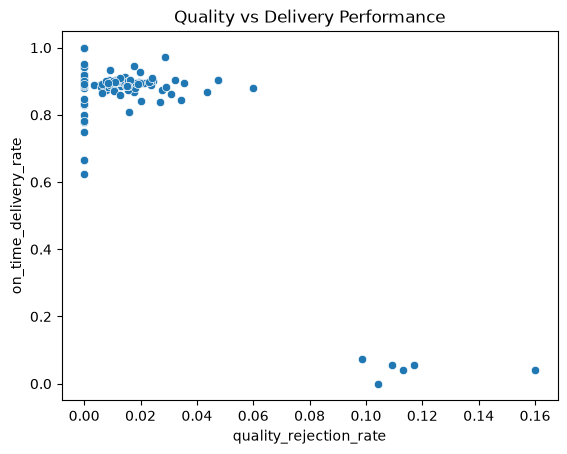

In [45]:
sns.scatterplot(
    data=supplier_features,
    x="quality_rejection_rate",
    y="on_time_delivery_rate"
)

plt.title("Quality vs Delivery Performance")
plt.show()

Outliers in price_competitiveness:
Q1: 0.9429115831612351
Q3: 1.044056051669349
IQR: 0.10114446850811376
Lower bound: 0.7911948803990645
Upper bound: 1.1957727544315195
Number of outliers: 0
--------------------------------------------------
Outliers in cost_variability:
Q1: 0.053354024897444195
Q3: 0.11105776940849231
IQR: 0.057703744511048115
Lower bound: -0.033201591869127973
Upper bound: 0.19761338617506446
Number of outliers: 0
--------------------------------------------------
Outliers in total_spend:
Q1: 138796.1325
Q3: 4492714.837499999
IQR: 4353918.704999999
Lower bound: -6392081.924999999
Upper bound: 11023592.895
Number of outliers: 11
--------------------------------------------------
Outliers in order_frequency:
Q1: 37.25
Q3: 539.75
IQR: 502.5
Lower bound: -716.5
Upper bound: 1293.5
Number of outliers: 10
--------------------------------------------------
Outliers in quality_rejection_rate:
Q1: 0.0
Q3: 0.019713345864661655
IQR: 0.019713345864661655
Lower bound: -0.02957001

In [47]:
features = [
    "price_competitiveness",
    "cost_variability",
    "total_spend",
    "order_frequency",
    "quality_rejection_rate",
    "on_time_delivery_rate"
]

In [48]:
supplier_features[features].skew()

price_competitiveness    -0.083209
cost_variability          0.707082
total_spend               6.635875
order_frequency           3.717419
quality_rejection_rate    3.011462
on_time_delivery_rate    -3.445044
dtype: float64

In [49]:
supplier_features[features].corr()

,price_competitiveness,cost_variability,total_spend,order_frequency,quality_rejection_rate,on_time_delivery_rate
price_competitiveness,1.000000,-0.042901,0.059236,0.055424,-0.005787,0.054397
cost_variability,-0.042901,1.000000,0.184900,0.032602,0.507433,-0.464426
total_spend,0.059236,0.184900,1.000000,0.728739,0.051369,0.005467
order_frequency,0.055424,0.032602,0.728739,1.000000,0.078642,0.000081
quality_rejection_rate,-0.005787,0.507433,0.051369,0.078642,1.000000,-0.834632
on_time_delivery_rate,0.054397,-0.464426,0.005467,0.000081,-0.834632,1.000000


In [50]:
# Late days
# Average late days → When they are late, how severe is the delay?

df["late_days"] = df["delivery_delay"].clip(lower=0)
average_late_days = (
    df.groupby("supplier_id")["late_days"]
      .mean()
      .rename("average_late_days")
)

supplier_features = supplier_features.merge(
    average_late_days,
    on="supplier_id",
    how="left"
)

In [51]:
supplier_features.head()

,price_competitiveness,cost_variability,total_spend,order_frequency,quality_rejection_rate,on_time_delivery_rate,average_late_days
supplier_id,,,,,,,
SUP-001,0.972818,0.090826,2180952.04,107,0.009346,0.934579,0.121495
SUP-002,0.970539,0.089811,83912380.83,4172,0.014621,0.891419,0.257910
SUP-003,1.090915,0.088498,10388962.85,456,0.017544,0.868421,0.370614
SUP-004,1.051534,0.084760,1426125.23,67,0.000000,0.910448,0.208955
SUP-005,1.099693,0.082324,2972062.85,127,0.007874,0.874016,0.330709


In [52]:
supplier_features["total_spend_log"] = np.log1p(
    supplier_features["total_spend"]
)

supplier_features["order_frequency_log"] = np.log1p(
    supplier_features["order_frequency"]
)

In [53]:
supplier_features.columns

Index(['price_competitiveness', 'cost_variability', 'total_spend',
       'order_frequency', 'quality_rejection_rate', 'on_time_delivery_rate',
       'average_late_days', 'total_spend_log', 'order_frequency_log'],
      dtype='object')

In [54]:
supplier_features = supplier_features.drop(
    columns=[
        "total_spend",
        "order_frequency"
    ]
)

In [55]:
supplier_features

,price_competitiveness,cost_variability,quality_rejection_rate,on_time_delivery_rate,average_late_days,total_spend_log,order_frequency_log
supplier_id,,,,,,,
SUP-001,0.972818,0.090826,0.009346,0.934579,0.121495,14.595273,4.682131
SUP-002,0.970539,0.089811,0.014621,0.891419,0.257910,18.245284,8.336390
SUP-003,1.090915,0.088498,0.017544,0.868421,0.370614,16.156255,6.124683
SUP-004,1.051534,0.084760,0.000000,0.910448,0.208955,14.170472,4.219508
SUP-005,1.099693,0.082324,0.007874,0.874016,0.330709,14.904767,4.852030
...,...,...,...,...,...,...,...
SUP-102,0.908411,0.060653,0.023944,0.911268,0.239437,15.554213,6.566672
SUP-103,1.071268,0.063343,0.012821,0.858974,0.384615,14.209570,5.056246
SUP-104,1.056981,0.054959,0.000000,0.952381,0.047619,12.148628,3.091042


In [56]:
corr = supplier_features.corr()
corr

,price_competitiveness,cost_variability,quality_rejection_rate,on_time_delivery_rate,average_late_days,total_spend_log,order_frequency_log
price_competitiveness,1.000000,-0.042901,-0.005787,0.054397,-0.065270,0.175010,0.079093
cost_variability,-0.042901,1.000000,0.507433,-0.464426,0.475892,0.388335,0.191377
quality_rejection_rate,-0.005787,0.507433,1.000000,-0.834632,0.874685,0.210629,0.217425
on_time_delivery_rate,0.054397,-0.464426,-0.834632,1.000000,-0.973648,-0.014233,-0.033594
average_late_days,-0.065270,0.475892,0.874685,-0.973648,1.000000,0.076355,0.101112
total_spend_log,0.175010,0.388335,0.210629,-0.014233,0.076355,1.000000,0.897523
order_frequency_log,0.079093,0.191377,0.217425,-0.033594,0.101112,0.897523,1.000000


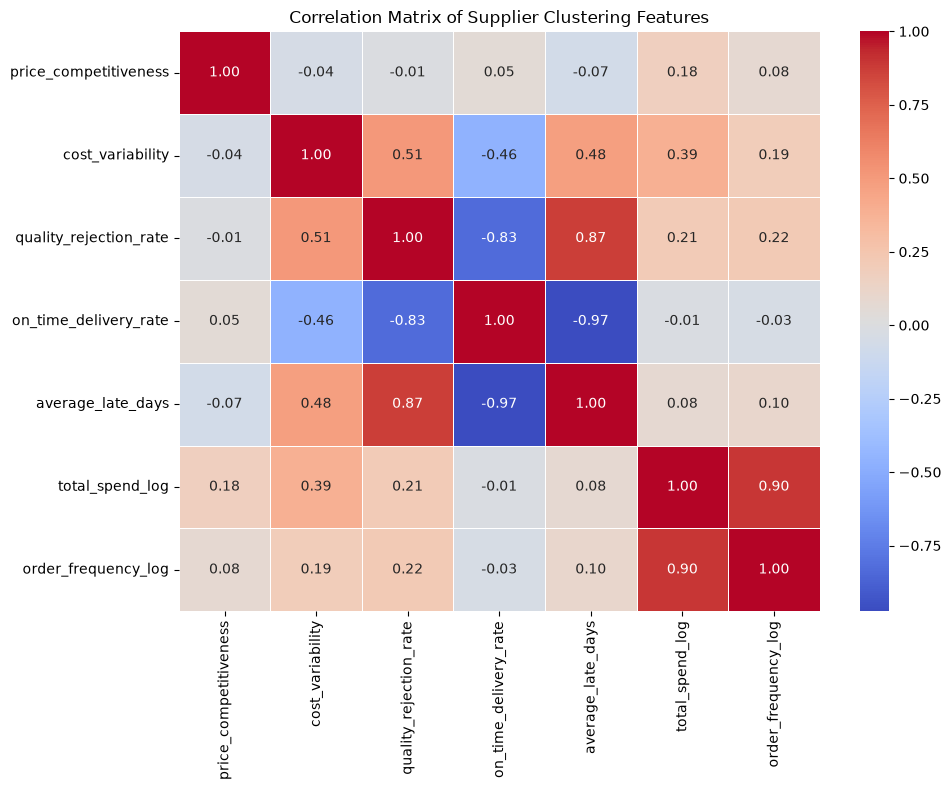

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Supplier Clustering Features")
plt.tight_layout()
plt.show()

In [58]:
features = [
    "price_competitiveness",
    "cost_variability",
    "quality_rejection_rate",
    "on_time_delivery_rate",
    "average_late_days",
    "total_spend_log",
    "order_frequency_log"
]

In [59]:
supplier_features[features].skew()

price_competitiveness    -0.083209
cost_variability          0.707082
quality_rejection_rate    3.011462
on_time_delivery_rate    -3.445044
average_late_days         3.864803
total_spend_log          -0.022218
order_frequency_log       0.030113
dtype: float64

- quality_rejection_rate	3.011	Highly right skewed	⚠️ Consider log/transform
- on_time_delivery_rate	-3.445	Highly left skewed	⚠️ Investigate/transform
- average_late_days	3.865	Highly right skewed	⚠️ Transform

In [60]:
supplier_features.drop(columns=["on_time_delivery_rate"], inplace=True)

In [61]:
supplier_features_new = supplier_features.copy()

In [62]:
supplier_features_new["quality_rejection_rate_log"] = np.log1p(
    supplier_features_new["quality_rejection_rate"]
)

supplier_features_new["average_late_days_log"] = np.log1p(
    supplier_features_new["average_late_days"]
)

In [63]:
supplier_features_new

,price_competitiveness,cost_variability,quality_rejection_rate,average_late_days,total_spend_log,order_frequency_log,quality_rejection_rate_log,average_late_days_log
supplier_id,,,,,,,,
SUP-001,0.972818,0.090826,0.009346,0.121495,14.595273,4.682131,0.009302,0.114663
SUP-002,0.970539,0.089811,0.014621,0.257910,18.245284,8.336390,0.014515,0.229452
SUP-003,1.090915,0.088498,0.017544,0.370614,16.156255,6.124683,0.017392,0.315259
SUP-004,1.051534,0.084760,0.000000,0.208955,14.170472,4.219508,0.000000,0.189757
SUP-005,1.099693,0.082324,0.007874,0.330709,14.904767,4.852030,0.007843,0.285712
...,...,...,...,...,...,...,...,...
SUP-102,0.908411,0.060653,0.023944,0.239437,15.554213,6.566672,0.023662,0.214657
SUP-103,1.071268,0.063343,0.012821,0.384615,14.209570,5.056246,0.012739,0.325422
SUP-104,1.056981,0.054959,0.000000,0.047619,12.148628,3.091042,0.000000,0.046520


In [64]:
supplier_features_new.drop(columns=["quality_rejection_rate","average_late_days"], inplace=True)

Feature	Business                    meaning
1) price_competitiveness: How competitive supplier pricing is
2) cost_variability	: Stability of supplier pricing
3) quality_rejection_rate: Quality performance
4) average_late_days: Delivery performance
5) total_spend_log: Supplier financial importance
6) order_frequency_log: Supplier relationship/activity

In [65]:
supplier_features_new

,price_competitiveness,cost_variability,total_spend_log,order_frequency_log,quality_rejection_rate_log,average_late_days_log
supplier_id,,,,,,
SUP-001,0.972818,0.090826,14.595273,4.682131,0.009302,0.114663
SUP-002,0.970539,0.089811,18.245284,8.336390,0.014515,0.229452
SUP-003,1.090915,0.088498,16.156255,6.124683,0.017392,0.315259
SUP-004,1.051534,0.084760,14.170472,4.219508,0.000000,0.189757
SUP-005,1.099693,0.082324,14.904767,4.852030,0.007843,0.285712
...,...,...,...,...,...,...
SUP-102,0.908411,0.060653,15.554213,6.566672,0.023662,0.214657
SUP-103,1.071268,0.063343,14.209570,5.056246,0.012739,0.325422
SUP-104,1.056981,0.054959,12.148628,3.091042,0.000000,0.046520


In [ ]:
supplier_features_new[
    ['quality_rejection_rate_log', 'average_late_days_log']
].skew()

In [66]:
features = [
    "price_competitiveness",
    "cost_variability",
    "quality_rejection_rate_log",
    "average_late_days_log",
    "total_spend_log",
    "order_frequency_log"
]

In [67]:
supplier_features_new[features].skew()

price_competitiveness        -0.083209
cost_variability              0.707082
quality_rejection_rate_log    2.906287
average_late_days_log         3.572275
total_spend_log              -0.022218
order_frequency_log           0.030113
dtype: float64

In [68]:
supplier_features_new.describe()

,price_competitiveness,cost_variability,total_spend_log,order_frequency_log,quality_rejection_rate_log,average_late_days_log
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,0.993467,0.080349,13.535252,4.888815,0.017457,0.362212
std,0.066226,0.036096,2.030046,1.673051,0.026156,0.528223
min,0.860772,0.014846,9.704333,1.386294,0.000000,0.000000
25%,0.942912,0.053354,11.840455,3.644080,0.000000,0.186604
50%,1.002002,0.065603,13.707189,4.855921,0.011462,0.231912
75%,1.044056,0.111058,15.317734,6.290737,0.019522,0.287189
max,1.161405,0.185699,18.245284,8.591373,0.148420,2.485338


In [71]:
for col in features:

    Q1 = supplier_features_new[col].quantile(0.25)
    Q3 = supplier_features_new[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = supplier_features_new[
        (supplier_features_new[col] < lower_bound) |
        (supplier_features_new[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


price_competitiveness
Lower bound: 0.7911948803990645
Upper bound: 1.1957727544315195
Number of outliers: 0

cost_variability
Lower bound: -0.033201591869127973
Upper bound: 0.19761338617506446
Number of outliers: 0

quality_rejection_rate_log
Lower bound: -0.02928233030464725
Upper bound: 0.048803883841078755
Number of outliers: 7

average_late_days_log
Lower bound: 0.03572472494736312
Upper bound: 0.4380683033595121
Number of outliers: 15

total_spend_log
Lower bound: 6.624537467745092
Upper bound: 20.53365187516964
Number of outliers: 0

order_frequency_log
Lower bound: -0.32590572935825657
Upper bound: 10.260722965802964
Number of outliers: 0


In [74]:
supplier_features_new[
    supplier_features_new["quality_rejection_rate_log"] > 0.048803883841078755
][["quality_rejection_rate_log"]].sort_values(
    "quality_rejection_rate_log",
    ascending=False
)

,quality_rejection_rate_log
supplier_id,
SUP-018,0.148420
SUP-046,0.110542
SUP-008,0.107086
SUP-029,0.103797
SUP-063,0.099091
SUP-078,0.093896
SUP-094,0.058269


In [75]:
supplier_features_new[
    supplier_features_new["average_late_days_log"] > 0.4380683033595121
][["average_late_days_log"]].sort_values(
    "average_late_days_log",
    ascending=False
)

,average_late_days_log
supplier_id,
SUP-078,2.485338
SUP-029,2.469599
SUP-008,2.459065
SUP-046,2.442065
SUP-018,2.437116
SUP-063,2.416658
SUP-088,0.847298
SUP-080,0.587787
SUP-058,0.510826


In [76]:
supplier_features_new[features].corr()

,price_competitiveness,cost_variability,quality_rejection_rate_log,average_late_days_log,total_spend_log,order_frequency_log
price_competitiveness,1.000000,-0.042901,-0.006010,-0.073349,0.175010,0.079093
cost_variability,-0.042901,1.000000,0.508995,0.474064,0.388335,0.191377
quality_rejection_rate_log,-0.006010,0.508995,1.000000,0.846663,0.217465,0.224068
average_late_days_log,-0.073349,0.474064,0.846663,1.000000,0.057392,0.083182
total_spend_log,0.175010,0.388335,0.217465,0.057392,1.000000,0.897523
order_frequency_log,0.079093,0.191377,0.224068,0.083182,0.897523,1.000000


In [77]:
supplier_features_new.drop(columns=["order_frequency_log"], inplace=True)

In [90]:
supplier_features_new = supplier_features_new.reset_index()
supplier_features_new

,supplier_id,price_competitiveness,cost_variability,total_spend_log,quality_rejection_rate_log,average_late_days_log
0,SUP-001,0.972818,0.090826,14.595273,0.009302,0.114663
1,SUP-002,0.970539,0.089811,18.245284,0.014515,0.229452
2,SUP-003,1.090915,0.088498,16.156255,0.017392,0.315259
3,SUP-004,1.051534,0.084760,14.170472,0.000000,0.189757
4,SUP-005,1.099693,0.082324,14.904767,0.007843,0.285712
...,...,...,...,...,...,...
101,SUP-102,0.908411,0.060653,15.554213,0.023662,0.214657
102,SUP-103,1.071268,0.063343,14.209570,0.012739,0.325422
103,SUP-104,1.056981,0.054959,12.148628,0.000000,0.046520
104,SUP-105,1.079207,0.064942,15.703526,0.008439,0.212922


In [91]:
X = supplier_features_new.drop(columns=["supplier_id"])
X

,price_competitiveness,cost_variability,total_spend_log,quality_rejection_rate_log,average_late_days_log
0,0.972818,0.090826,14.595273,0.009302,0.114663
1,0.970539,0.089811,18.245284,0.014515,0.229452
2,1.090915,0.088498,16.156255,0.017392,0.315259
3,1.051534,0.084760,14.170472,0.000000,0.189757
4,1.099693,0.082324,14.904767,0.007843,0.285712
...,...,...,...,...,...
101,0.908411,0.060653,15.554213,0.023662,0.214657
102,1.071268,0.063343,14.209570,0.012739,0.325422
103,1.056981,0.054959,12.148628,0.000000,0.046520
104,1.079207,0.064942,15.703526,0.008439,0.212922


In [47]:
# entity

from dataclasses import dataclass
from pathlib import Path

#entity
@dataclass(frozen=True)
class FeatureEngineeringConfig:
    # These values are set in the config.yaml file and passed to the FeatureEngineeringConfig class
    root_dir: Path  # input data set
    data_path: Path  # directory to save the processed data


In [48]:
# configuration manager
from src.Supplier_clustering.constants import *
from src.Supplier_clustering.utils.common import read_yaml, create_directories

In [49]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH,
        schema_filepath = SCHEMA_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        self.schema = read_yaml(schema_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_feature_engineering_config(self) -> FeatureEngineeringConfig:
        config = self.config.feature_engineering

        create_directories([config.root_dir])

        feature_engineering_config = FeatureEngineeringConfig(
            root_dir=config.root_dir,
            data_path=config.data_path

        )

        return feature_engineering_config

In [50]:
from src.Supplier_clustering.utils.logger import logger

In [51]:
class FeatureEngineering:

    def __init__(self, config: FeatureEngineeringConfig):
        self.config = config

    def engineer_features(self):

        # ---------------------------------------------------------
        # 1. Read cleaned data
        # ---------------------------------------------------------
        data = pd.read_csv(self.config.data_path)

        logger.info(f"Input data shape: {data.shape}")

        # ---------------------------------------------------------
        # 2. Calculate supplier-level features
        # ---------------------------------------------------------

        date_columns=['order_date','promised_delivery_date','actual_delivery_date']

        for col in date_columns:
            data[col] = pd.to_datetime(data[col])

        data['delivery_delay'] = (data['actual_delivery_date'] - data['promised_delivery_date']).dt.days

        # Total spend per supplier
        total_spend = (
            data.groupby("supplier_id")["line_total"]
            .sum()
        )

        # Number of orders per supplier
        order_frequency = (
            data.groupby("supplier_id")["po_id"]
            .nunique()
        )

        # Average delivery delay per supplier
        average_delivery_delay = (
            data.groupby("supplier_id")["delivery_delay"]
            .mean()
        )

        # Quality rejection rate
        quality_rejection_rate = (
            data.groupby("supplier_id")["quality_rejected"]
            .mean()
        )

        data['on_time'] = data['delivery_delay'].apply(lambda x: 1 if x<=0 else 0)

        # On-time delivery rate
        on_time_delivery_rate = (
            data.groupby("supplier_id")["on_time"]
            .mean()
        )

        # Late days
        # Average late days → When they are late, how severe is the delay?
        data["late_days"] = data["delivery_delay"].clip(lower=0)
        average_late_days = (data.groupby("supplier_id")["late_days"].mean().rename("average_late_days"))
        
        #data = data.merge(average_late_days,on="supplier_id",how="left")

        # ---------------------------------------------------------
        # 3. Price competitiveness
        # ---------------------------------------------------------
        item_avg_price = data.groupby('item')['unit_price'].mean().reset_index().rename(columns={"unit_price": "item_avg_price"})
        #
        # price_ratio = supplier price / average item price
        data = data.merge(item_avg_price, on='item', how='left')
        data['price_ratio']= data['unit_price']/data['item_avg_price']
        #
        # Lower value = more price competitive
        # Around 1 = close to market average
        # Higher value = more expensive
        #
        price_competitiveness = (
            data.groupby("supplier_id")["price_ratio"]
            .mean()
        )

        # ---------------------------------------------------------
        # 4. Cost variability
        # ---------------------------------------------------------
        #
        # Calculate coefficient of variation of supplier prices.
        #
        # CV = standard deviation / mean
        #
        data["item_supplier_price_cv"] = (
            data.groupby(["supplier_id", "item"])["unit_price"]
            .transform(lambda x: x.std() / x.mean() if x.mean() != 0 else 0)
        )
        cost_variability = (
            data.groupby("supplier_id")["item_supplier_price_cv"].mean())

        # ---------------------------------------------------------
        # 5. Create supplier-level dataset
        # ---------------------------------------------------------

        engineered_data = pd.DataFrame({
            "supplier_id": total_spend.index,

            "price_competitiveness":
                price_competitiveness.reindex(total_spend.index),

            "cost_variability":
                cost_variability.reindex(total_spend.index),

            "total_spend":
                total_spend,

            "order_frequency":
                order_frequency.reindex(total_spend.index),

            "average_delivery_delay":
                average_delivery_delay.reindex(total_spend.index),

            "quality_rejection_rate":
                quality_rejection_rate.reindex(total_spend.index),

            "on_time_delivery_rate":
                on_time_delivery_rate.reindex(total_spend.index),

            "average_late_days":
                average_late_days.reindex(total_spend.index)
        })

        # ---------------------------------------------------------
        # 6. Reset index
        # ---------------------------------------------------------

        engineered_data = engineered_data.reset_index(drop=True)

        logger.info(
            f"Supplier-level feature shape: {engineered_data.shape}"
        )

        logger.info(
            f"Supplier-level features created: "
            f"{list(engineered_data.columns)}"
        )

        # ---------------------------------------------------------
        # 7. Check missing values
        # ---------------------------------------------------------

        if engineered_data.isnull().sum().sum() > 0:

            logger.warning(
                "Missing values detected in supplier features"
            )

            logger.warning(
                engineered_data.isnull().sum()
            )

        # ---------------------------------------------------------
        # 8. Save engineered features
        # ---------------------------------------------------------

        engineered_data.to_csv(
            os.path.join(
                self.config.root_dir,
                "engineered_data.csv"
            ),
            index=False
        )

        logger.info(
            "Engineered features saved successfully"
        )

        print(engineered_data.head())
        print(engineered_data.shape)

        return engineered_data

In [52]:
#pipeline
try:
    config = ConfigurationManager()
    feature_engineering_config = config.get_feature_engineering_config()
    feature_engineering = FeatureEngineering(config=feature_engineering_config)
    feature_engineering.engineer_features()
except Exception as e:
    raise e

[2026-08-31 17:27:59,943: INFO: common: yaml file: config\config.yaml loaded successfully]
[2026-08-31 17:27:59,956: INFO: common: yaml file: params.yaml loaded successfully]


[2026-08-31 17:27:59,973: INFO: common: yaml file: schema.yaml loaded successfully]
[2026-08-31 17:27:59,975: INFO: common: created directory at: artifacts]
[2026-08-31 17:27:59,976: INFO: common: created directory at: artifacts/feature_engineering]
[2026-08-31 17:28:00,142: INFO: 2741307819: Input data shape: (47128, 16)]
[2026-08-31 17:28:00,565: INFO: 2741307819: Supplier-level feature shape: (106, 9)]
[2026-08-31 17:28:00,565: INFO: 2741307819: Supplier-level features created: ['supplier_id', 'price_competitiveness', 'cost_variability', 'total_spend', 'order_frequency', 'average_delivery_delay', 'quality_rejection_rate', 'on_time_delivery_rate', 'average_late_days']]
[2026-08-31 17:28:00,582: INFO: 2741307819: Engineered features saved successfully]
  supplier_id  price_competitiveness  ...  on_time_delivery_rate  average_late_days
0     SUP-001               0.972818  ...               0.934579           0.121495
1     SUP-002               0.970539  ...               0.891419    

### Scaling the features using StandardScaler

In [78]:
features = [
    "price_competitiveness",
    "cost_variability",
    "quality_rejection_rate_log",
    "average_late_days_log",
    "total_spend_log"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    supplier_features_new[features]
)

In [85]:

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features,
    index=supplier_features.index
)

X_scaled_df.describe()

,price_competitiveness,cost_variability,quality_rejection_rate_log,average_late_days_log,total_spend_log
count,1.060000e+02,1.060000e+02,1.060000e+02,1.060000e+02,1.060000e+02
mean,-2.794410e-15,-3.016455e-16,-1.990022e-17,-7.600053e-17,-2.304236e-17
std,1.004751e+00,1.004751e+00,1.004751e+00,1.004751e+00,1.004751e+00
min,-2.013202e+00,-1.823323e+00,-6.706042e-01,-6.889748e-01,-1.896074e+00
25%,-7.670114e-01,-7.514307e-01,-6.706042e-01,-3.340301e-01,-8.388222e-01
50%,1.294904e-01,-4.104728e-01,-2.303057e-01,-2.478469e-01,8.509866e-02
75%,7.675101e-01,8.547975e-01,7.930388e-02,-1.427024e-01,8.822217e-01
max,2.547886e+00,2.932488e+00,5.030856e+00,4.038469e+00,2.331183e+00


Standardize them.
Run K-Means for K=2–7.
Evaluate silhouette/Davies-Bouldin/Calinski-Harabasz.
Run DBSCAN.
Profile the resulting clusters.
Then test whether adding delivery_variability or another feature improves the clustering.

## K Means

In [86]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled_df)

    inertia.append(kmeans.inertia_)

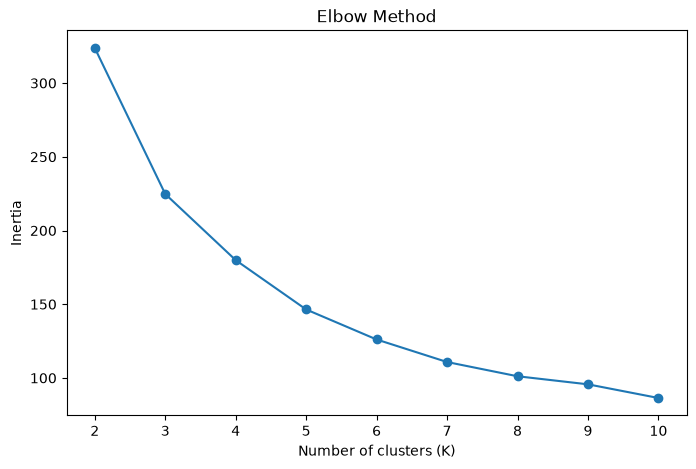

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [88]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled_df)

    score = silhouette_score(X_scaled_df, labels)

    silhouette_scores.append(score)

    print(f"K={k}: Silhouette Score={score:.4f}")

K=2: Silhouette Score=0.6345
K=3: Silhouette Score=0.3097
K=4: Silhouette Score=0.2971
K=5: Silhouette Score=0.3067
K=6: Silhouette Score=0.3237
K=7: Silhouette Score=0.3089
K=8: Silhouette Score=0.3180
K=9: Silhouette Score=0.2964
K=10: Silhouette Score=0.3164


In [ ]:
supplier_features = supplier_features.reset_index()
supplier_features

In [ ]:
X = supplier_features.drop(columns=['supplier_id'])
X